In [1]:
import xarray as xr

ds = xr.open_dataset('ADCP_2012to2014_0N140W_daily.cdf',engine='netcdf4')
ds['depth'] = ds.depth*-1

In [2]:
ds.time[-300]

<xarray.DataArray 'time' ()> Size: 8B
array('2014-03-07T12:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2014-03-07T12:00:00
Attributes:
    FORTRAN_format:  
    type:            EVEN
    point_spacing:   even

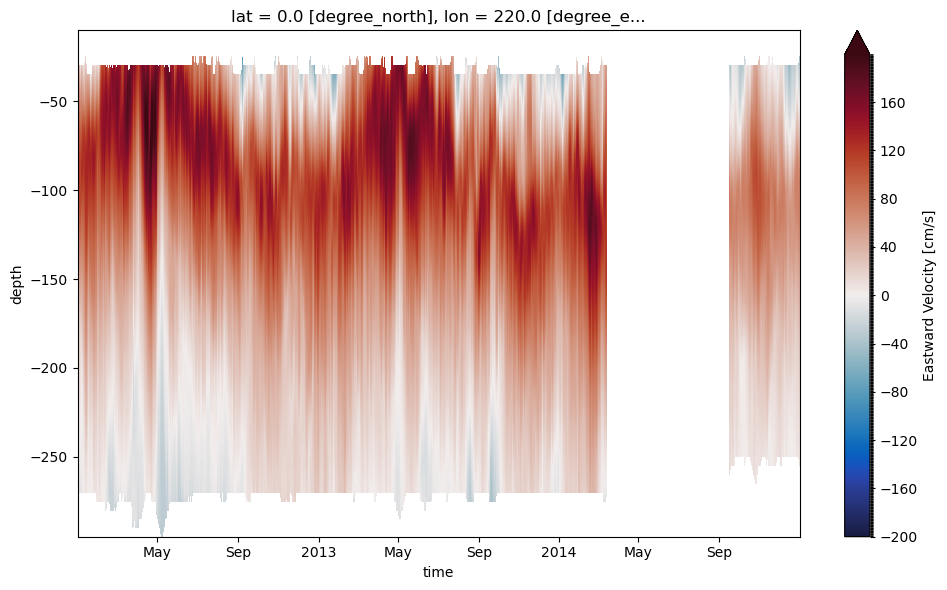

In [3]:
import numpy as np
import cmocean.cm as cmo
import matplotlib.pyplot as plt

levels = np.arange(-200.0,200.0,0.5)
levels2 = np.arange(-200.0,200.0,50)
fig, ax = plt.subplots(figsize=(10,6))
ds.u_1205[:,:,0,0].plot.contourf(ax=ax,levels=levels,x='time',y='depth',cmap=cmo.balance)
# ds.u_1205[:,:,0,0].plot.contour(ax=ax,levels=levels2,x='time',y='depth',colors='k',linewidths=0.5)
plt.tight_layout()

In [4]:
ds

<xarray.Dataset> Size: 1MB
Dimensions:  (time: 1096, depth: 58, lat: 1, lon: 1)
Coordinates:
  * time     (time) datetime64[ns] 9kB 2012-01-01T12:00:00 ... 2014-12-31T12:...
  * depth    (depth) float32 232B -10.0 -15.0 -20.0 ... -285.0 -290.0 -295.0
  * lat      (lat) float32 4B 0.0
  * lon      (lon) float32 4B 220.0
Data variables:
    u_1205   (time, depth, lat, lon) float32 254kB ...
    QU_5205  (time, depth, lat, lon) float32 254kB ...
    v_1206   (time, depth, lat, lon) float32 254kB ...
    QV_5206  (time, depth, lat, lon) float32 254kB ...
Attributes:
    platform_code:                0n140w
    site_code:                    0n140w
    wmo_platform_code:            51311
    array:                        TAO/TRITON
    Request_for_acknowledgement:  If you use these data in publications or pr...
    Data_Source:                  Global Tropical Moored Buoy Array Project O...
    File_info:                    Contact: Dai.C.McClurg@noaa.gov
    missing_value:                1e+35
    _FillValue:                   1e+35
    CREATION_DATE:                13:44 17-AUG-2024

In [5]:
da = ds.v_1206[:-300,20,0,0]
# first filter out low frequencies (> 15 days) to see high-frequency
highfreq = da - da.rolling(time=15, center=True).mean().dropna(dim="time")

/var/folders/8f/1b9jykm565z0yjl1_pkz3tt40000gn/T/ipykernel_51036/2765382318.py:9: RuntimeWarning: divide by zero encountered in divide
  ax.semilogy(1/f/86400, Pxx)


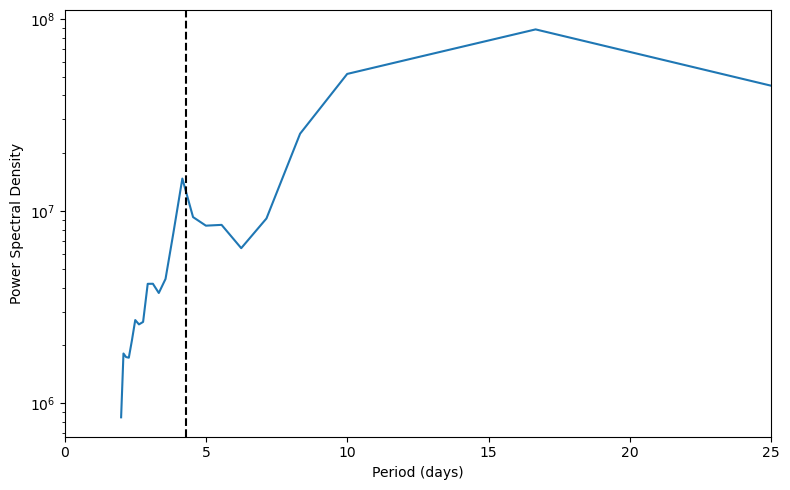

In [6]:
from scipy.signal import welch

# spectrum of the timeseries
fs = 1/86400  # 1 sample per day
f, Pxx = welch(highfreq, fs=fs, nperseg=50, detrend='linear')
fig, ax = plt.subplots(figsize=(8,5))
ax.semilogy(1/f/86400, Pxx)
ax.set_xlim(0,25)
ax.set_xlabel('Period (days)')
ax.set_ylabel('Power Spectral Density')
ax.axvline(4.3, color='k', linestyle='--')
plt.tight_layout()
plt.show()


/var/folders/8f/1b9jykm565z0yjl1_pkz3tt40000gn/T/ipykernel_51036/1587659175.py:11: RuntimeWarning: divide by zero encountered in divide
  ax[0].semilogy(1/f/86400, Pxx)
/var/folders/8f/1b9jykm565z0yjl1_pkz3tt40000gn/T/ipykernel_51036/1587659175.py:23: RuntimeWarning: divide by zero encountered in divide
  ax[1].semilogy(1/f/86400, Pxx)


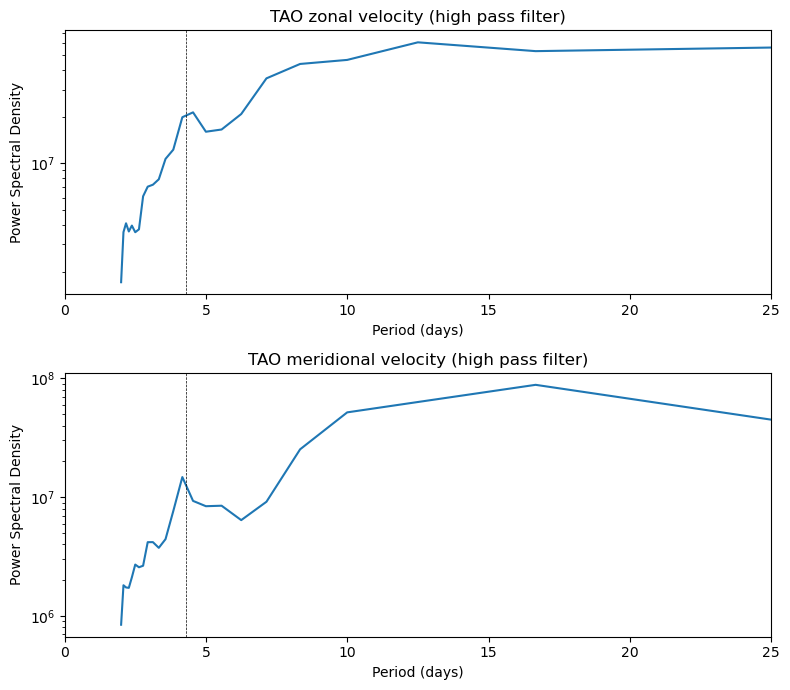

In [7]:
from scipy.signal import welch
fig, ax = plt.subplots(figsize=(8,7),nrows=2)

# spectrum of the timeseries
da = ds.u_1205[:-300,20,0,0]
# first filter out low frequencies (> 15 days) to see high-frequency
highfreq = da - da.rolling(time=15, center=True).mean().dropna(dim="time")
fs = 1/86400  # 1 sample per day
f, Pxx = welch(highfreq, fs=fs, nperseg=50, detrend='linear')
ax[0].semilogy(1/f/86400, Pxx)
ax[0].set_xlim(0,25)
ax[0].set_title('TAO zonal velocity (high pass filter)')
ax[0].set_xlabel('Period (days)')
ax[0].set_ylabel('Power Spectral Density')
ax[0].axvline(4.3, color='k', linestyle='--',linewidth=0.5)

da = ds.v_1206[:-300,20,0,0]
# first filter out low frequencies (> 15 days) to see high-frequency
highfreq = da - da.rolling(time=15, center=True).mean().dropna(dim="time")
fs = 1/86400  # 1 sample per day
f, Pxx = welch(highfreq, fs=fs, nperseg=50, detrend='linear')
ax[1].semilogy(1/f/86400, Pxx)
ax[1].set_xlim(0,25)
ax[1].set_title('TAO meridional velocity (high pass filter)')
ax[1].set_xlabel('Period (days)')
ax[1].set_ylabel('Power Spectral Density')
ax[1].axvline(4.3, color='k', linestyle='--',linewidth=0.5)

plt.tight_layout()
plt.show()


In [12]:
ds = xr.open_dataset('adcp_xyzt_2014to2016_daily.cdf',engine='netcdf4')
ds['depth'] = ds.depth*-1

In [13]:
ds = ds.sel(lon=220.0,lat=0.0)

In [19]:
ds

<xarray.Dataset> Size: 833kB
Dimensions:  (depth: 94, time: 1096)
Coordinates:
    lon      float32 4B 220.0
    lat      float32 4B 0.0
  * depth    (depth) float32 376B -10.0 -15.0 -20.0 ... -465.0 -470.0 -475.0
  * time     (time) datetime64[ns] 9kB 2014-01-01T12:00:00 ... 2016-12-31T12:...
Data variables:
    U_1205   (depth, time) float32 412kB 1e+35 1e+35 1e+35 ... 1e+35 1e+35 1e+35
    V_1206   (depth, time) float32 412kB ...
Attributes:
    array:                        TAO/TRITON
    Data_Source:                  GTMBA Project Office/NOAA/PMEL
    Data_info:                    Contact Paul Freitag: 206-526-6727
    File_info:                    Contact Dai McClurg: Dai.C.McClurg@noaa.gov
    Request_for_acknowledgement:  If you use these data in publications or pr...
    missing_value:                1e+35
    _FillValue:                   1e+35

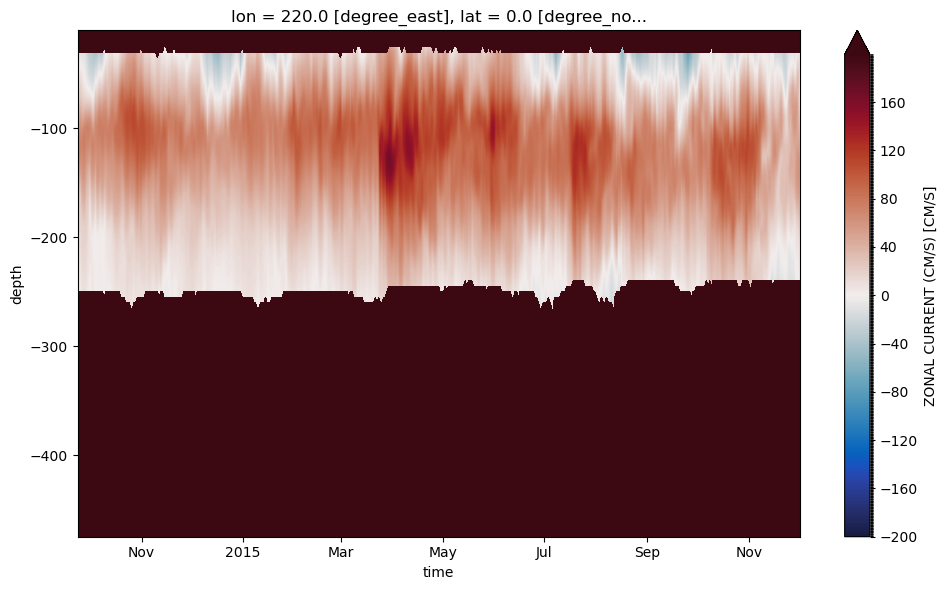

In [29]:
levels = np.arange(-200.0,200.0,0.5)
levels2 = np.arange(-200.0,200.0,50)
fig, ax = plt.subplots(figsize=(10,6))
ds.U_1205[:,265:700].plot.contourf(ax=ax,levels=levels,x='time',y='depth',cmap=cmo.balance)
# ds.u_1205[:,:,0,0].plot.contour(ax=ax,levels=levels2,x='time',y='depth',colors='k',linewidths=0.5)
plt.tight_layout()

In [ ]:
da = ds.U_1205

/var/folders/8f/1b9jykm565z0yjl1_pkz3tt40000gn/T/ipykernel_51036/31054854.py:11: RuntimeWarning: divide by zero encountered in divide
  ax[0].semilogy(1/f/86400, Pxx)
/var/folders/8f/1b9jykm565z0yjl1_pkz3tt40000gn/T/ipykernel_51036/31054854.py:23: RuntimeWarning: divide by zero encountered in divide
  ax[1].semilogy(1/f/86400, Pxx)


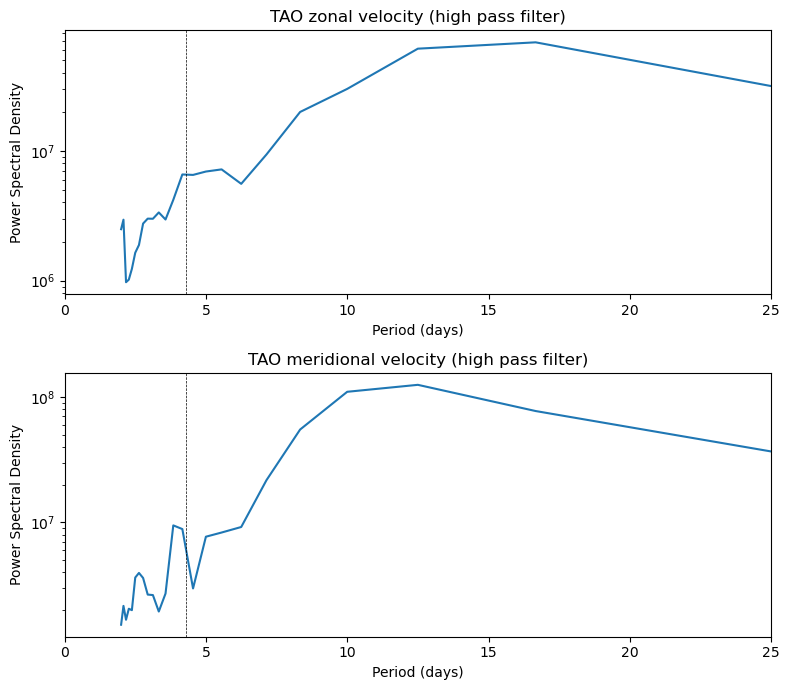

In [30]:
from scipy.signal import welch
# first filter out low frequencies (> 25 days) to see high-frequency
fig, ax = plt.subplots(figsize=(8,7),nrows=2)

# spectrum of the timeseries
da = ds.U_1205[20,265:700]
# first filter out low frequencies (> 15 days) to see high-frequency
highfreq = da - da.rolling(time=15, center=True).mean().dropna(dim="time")
fs = 1/86400  # 1 sample per day
f, Pxx = welch(highfreq, fs=fs, nperseg=50, detrend='linear')
ax[0].semilogy(1/f/86400, Pxx)
ax[0].set_xlim(0,25)
ax[0].set_title('TAO zonal velocity (high pass filter)')
ax[0].set_xlabel('Period (days)')
ax[0].set_ylabel('Power Spectral Density')
ax[0].axvline(4.3, color='k', linestyle='--',linewidth=0.5)

da = ds.V_1206[20,265:700]
# first filter out low frequencies (> 15 days) to see high-frequency
highfreq = da - da.rolling(time=15, center=True).mean().dropna(dim="time")
fs = 1/86400  # 1 sample per day
f, Pxx = welch(highfreq, fs=fs, nperseg=50, detrend='linear')
ax[1].semilogy(1/f/86400, Pxx)
ax[1].set_xlim(0,25)
ax[1].set_title('TAO meridional velocity (high pass filter)')
ax[1].set_xlabel('Period (days)')
ax[1].set_ylabel('Power Spectral Density')
ax[1].axvline(4.3, color='k', linestyle='--',linewidth=0.5)

plt.tight_layout()
plt.show()
